In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets,transforms
from torchvision.transforms import ToTensor

In [4]:
train_data=datasets.FashionMNIST(root='data2',
                                 train=True,
                                 download=True,
                                 transform=ToTensor(),
                                 target_transform=None)
test_data=datasets.FashionMNIST(root='data2',
                                train=False,
                                download=True,
                                transform=ToTensor(),
                                target_transform=None)
    

100%|██████████████████████████| 26421880/26421880 [00:12<00:00, 2161434.77it/s]


Extracting data2/FashionMNIST/raw/train-images-idx3-ubyte.gz to data2/FashionMNIST/raw



100%|█████████████████████████████████| 29515/29515 [00:00<00:00, 168396.34it/s]


Extracting data2/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data2/FashionMNIST/raw



100%|█████████████████████████████| 4422102/4422102 [00:04<00:00, 995298.65it/s]


Extracting data2/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data2/FashionMNIST/raw



100%|██████████████████████████████████| 5148/5148 [00:00<00:00, 7417477.50it/s]

Extracting data2/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data2/FashionMNIST/raw



In [8]:
image,label=train_data[4]

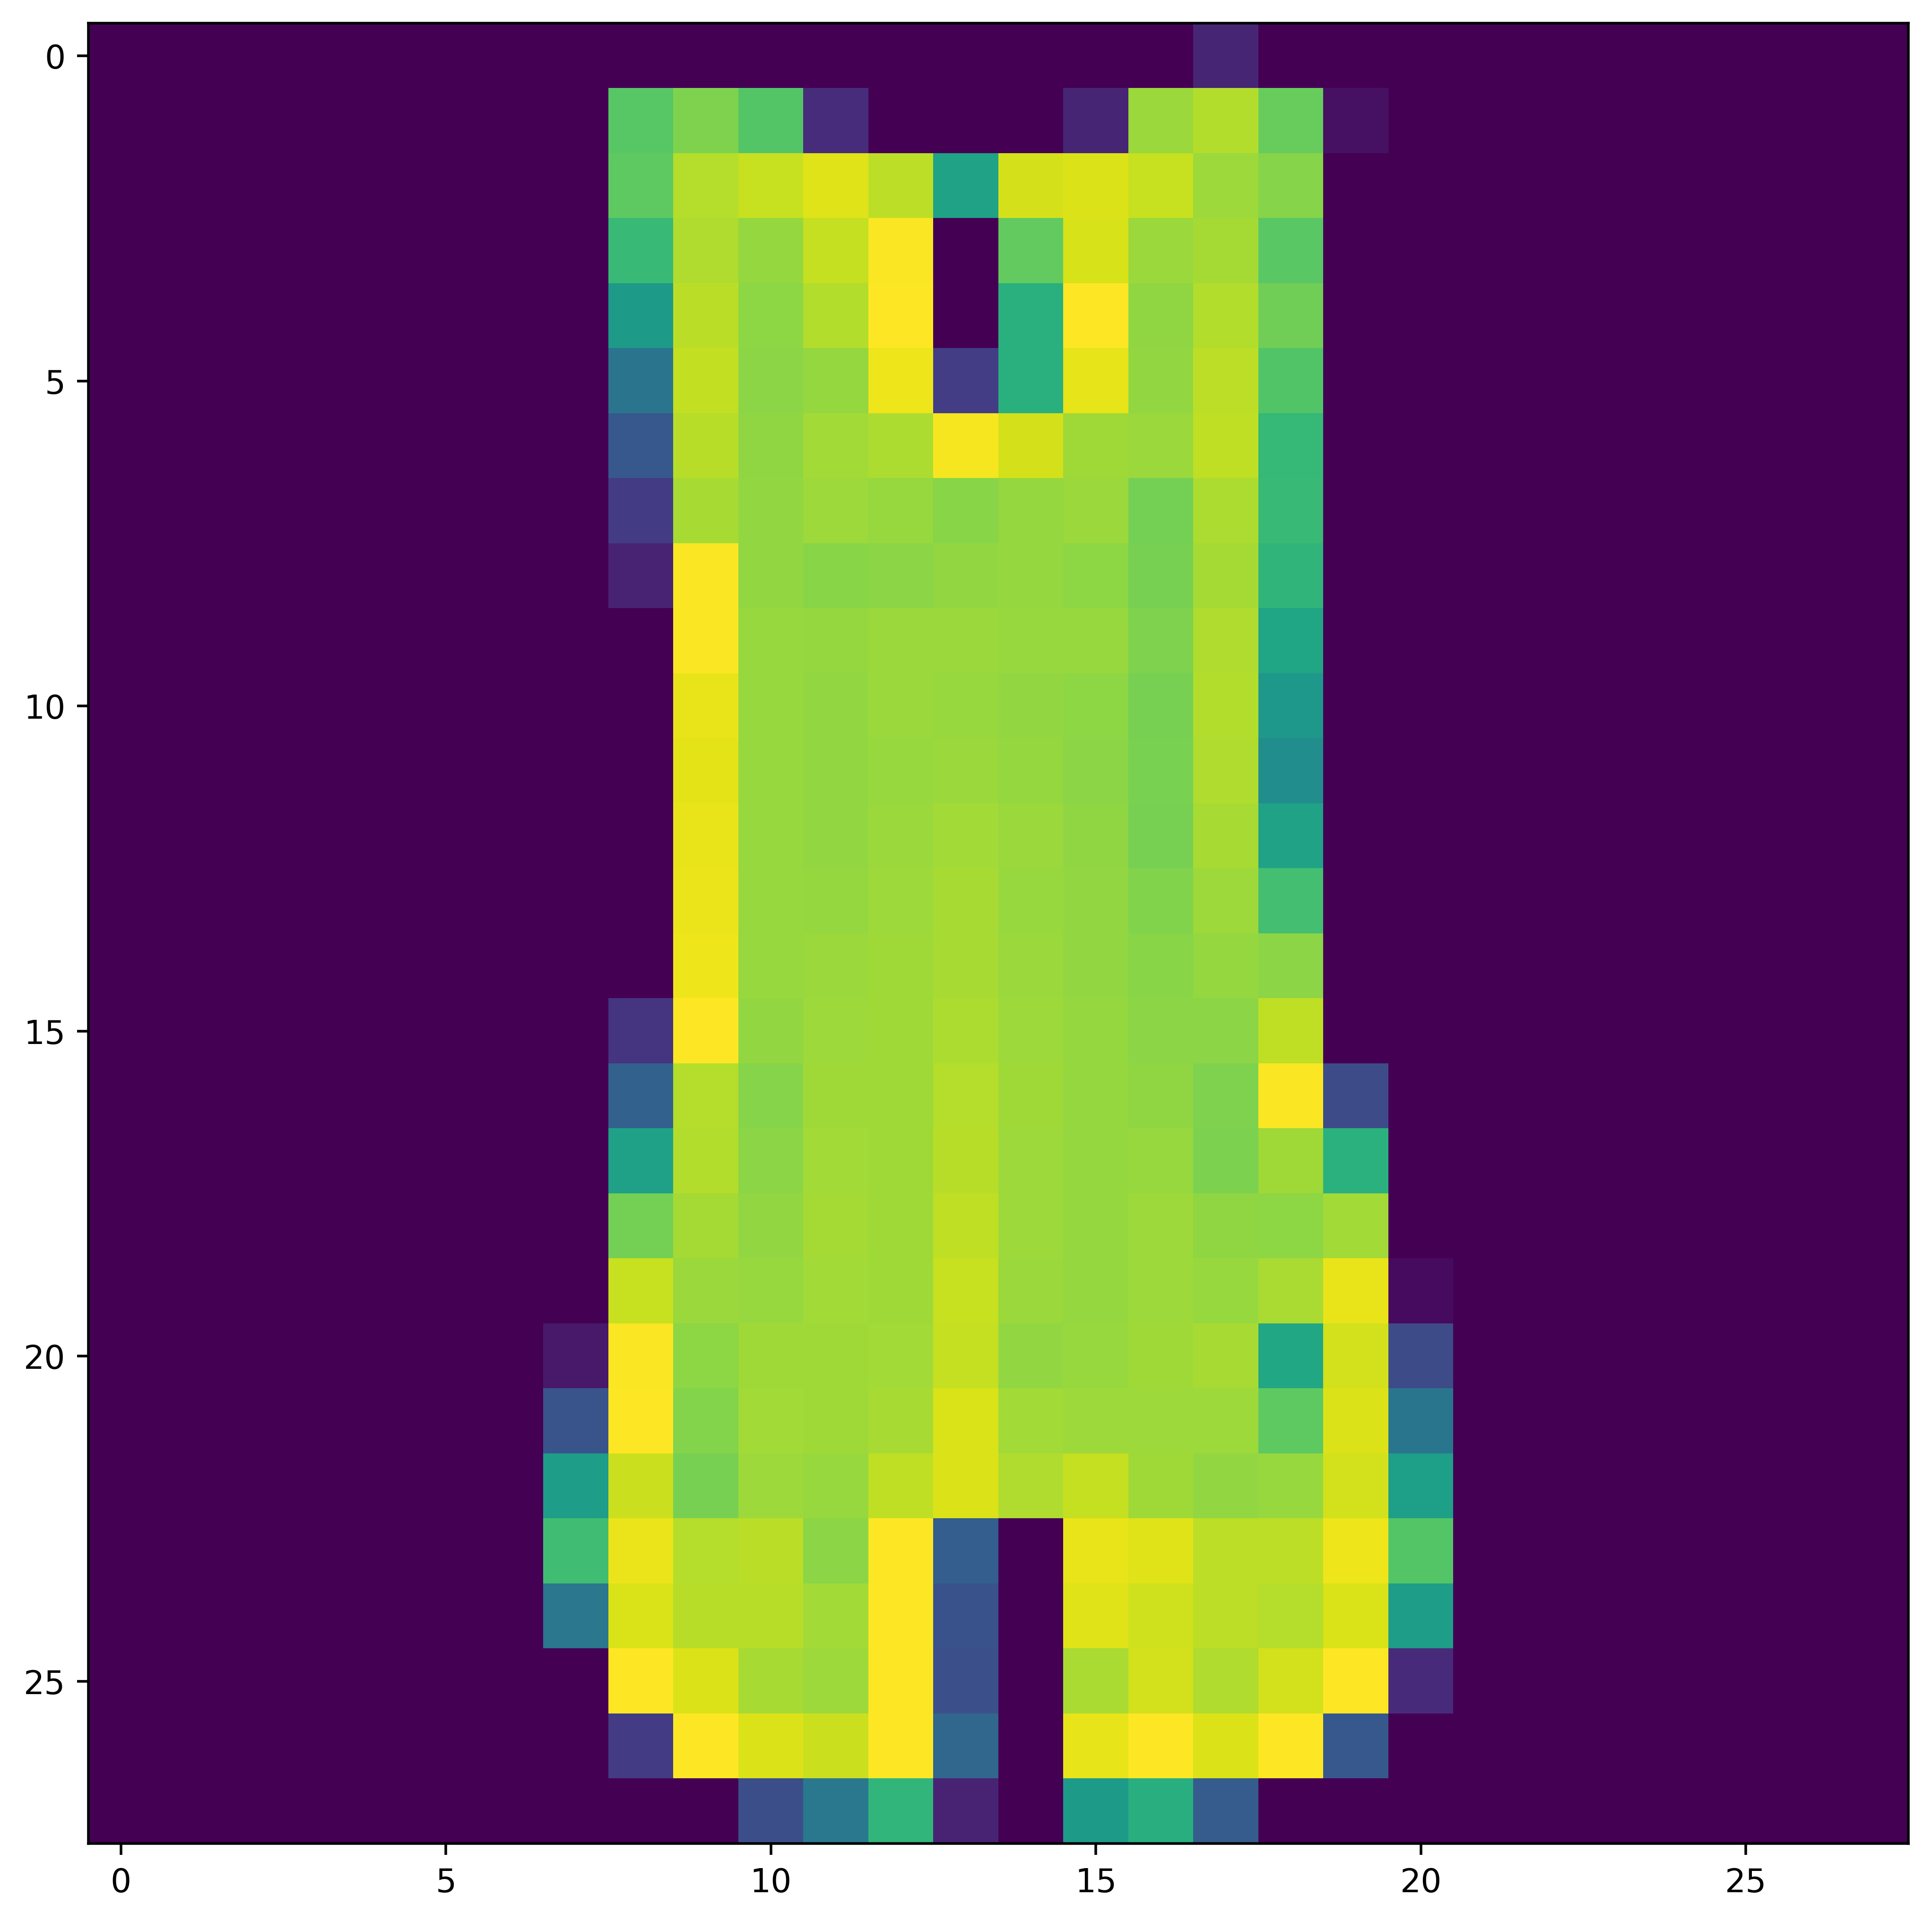

In [9]:
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(10,10),dpi=500)
plt.imshow(image.squeeze())

In [11]:
category=train_data.classes

In [12]:
category

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [14]:
train_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [17]:
row=4
cols=4
fig=plt.figure(figsize=(10,10),dpi=1000)
for i in range(1,cols*row+1,1):
    random=torch.randint(1,len(train_data),size=[1]).item()
    image,l=train_data[random]
    fig.add_subplot(row,cols,i)
    plt.imshow(image.squeeze())
    plt.title(category[l])
    plt.axis(False)
    
    

In [18]:
from torch.utils.data import DataLoader


In [19]:
train_dataloader=DataLoader(dataset=train_data,
                            batch_size=32,
                            shuffle=True)

In [21]:
list(train_dataloader)

[[tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            ...,
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
  
  
          [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            ...,
            [0.0000, 0.0000, 0.0000,  ..., 0.1647, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.2588, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0392, 0.0000, 0.0000]]],
  
  
          [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]

In [23]:
test_dataloader=DataLoader(dataset=test_data,
                           batch_size=32,
                           shuffle=False)

In [24]:
train_features,train_labels=next(iter(train_dataloader))